# MICrONS20 independent current-clamp simulation

This experiment tests all 20 processed MICrONS morphologies in one BioNet run.

Every cell receives:

- the same Allen-derived provisional perisomatic membrane model;
- the same 0.60 nA somatic current step;
- no recurrent synapses;
- no outside-selected20 spike input.

The purpose is **simulation compatibility and morphology-dependent response QC**, not physiological validation.


In [1]:
from microns20.config import find_project_root
from microns20.population_simulation import (
    compile_microns20_independent_mechanisms,
    plot_population_spike_counts,
    plot_population_spike_raster,
    plot_population_voltage_traces,
    prepare_microns20_independent_run,
    run_microns20_independent,
    save_microns20_independent_summary,
    summarize_microns20_independent,
    validate_microns20_independent_assets,
)

project_root = find_project_root()
project_root


PosixPath('<PROJECT_ROOT>')

## 1. Validate the 20-cell experiment inputs

In [2]:
audit = validate_microns20_independent_assets(project_root)

print("Selected cells:", audit["n_cells"])
print("L4a:", audit["n_l4a"])
print("L4b:", audit["n_l4b"])
print("Allen mechanisms:", audit["n_modfiles"])
print("Temperature:", audit["celsius"], "°C")
print("Initial voltage:", audit["v_init_mv"], "mV")

display(
    audit["population"][
        [
            "model_node_id",
            "nucleus_id",
            "pt_root_id",
            "microns_mtype",
            "morphology_name",
        ]
    ]
)


Selected cells: 20
L4a: 9
L4b: 11
Allen mechanisms: 16
Temperature: 34.0 °C
Initial voltage: -84.59716796875 mV


,model_node_id,nucleus_id,pt_root_id,microns_mtype,morphology_name
0,0,260303,864691136275332030,L4a,model_000_nucleus_260303_root_8646911362753320...
1,1,260621,864691135563052513,L4b,model_001_nucleus_260621_root_8646911355630525...
2,2,260625,864691136043283030,L4b,model_002_nucleus_260625_root_8646911360432830...
3,3,260628,864691135375888840,L4a,model_003_nucleus_260628_root_8646911353758888...
4,4,260648,864691136336274867,L4b,model_004_nucleus_260648_root_8646911363362748...
5,5,260689,864691137022275182,L4b,model_005_nucleus_260689_root_8646911370222751...
6,6,262547,864691135375895752,L4a,model_006_nucleus_262547_root_8646911353758957...
7,7,262654,864691135783322704,L4b,model_007_nucleus_262654_root_8646911357833227...
8,8,262698,864691135294441654,L4b,model_008_nucleus_262698_root_8646911352944416...
9,9,262810,864691135369693945,L4b,model_009_nucleus_262810_root_8646911353696939...


## 2. Build the independent 20-cell BioNet experiment

The structural SONATA package in `data/processed/sonata/` is not modified. This experiment creates its own run-specific network under `runs/`.


In [3]:
run_info = prepare_microns20_independent_run(
    project_root,
    overwrite=True,
)

{
    key: value
    for key, value in run_info.items()
    if key != "node_mapping"
}


{'run_dir': PosixPath('<PROJECT_ROOT>/runs/microns20_independent_060'),
 'config_file': PosixPath('<PROJECT_ROOT>/runs/microns20_independent_060/config.json'),
 'network_dir': PosixPath('<PROJECT_ROOT>/runs/microns20_independent_060/network'),
 'components_dir': PosixPath('<PROJECT_ROOT>/runs/microns20_independent_060/components'),
 'mechanisms_dir': PosixPath('<PROJECT_ROOT>/runs/microns20_independent_060/components/mechanisms'),
 'population_name': 'microns20_independent',
 'n_cells': 20,
 'n_l4a': 9,
 'n_l4b': 11,
 'celsius': 34.0,
 'v_init_mv': -84.59716796875,
 'current_clamp_amp_na': 0.6,
 'current_clamp_delay_ms': 200.0,
 'current_clamp_duration_ms': 500.0,
 'tstop_ms': 1000.0,
 'dt_ms': 0.1,
 'model_processing': 'microns_perisomatic_preserve_morphology',
 'physiology_status': 'allen_derived_provisional_not_microns_fitted'}

## 3. Compile the run-local NMODL mechanisms

Restart the `NeuroAI` kernel before running this notebook if a different BioNet experiment has already been run in the same Python process.


In [4]:
mechanism_library = compile_microns20_independent_mechanisms(
    run_info
)
mechanism_library


PosixPath('<PROJECT_ROOT>/runs/microns20_independent_060/components/mechanisms/x86_64/libnrnmech.so')

## 4. Run all 20 cells

In [5]:
output_dir = run_microns20_independent(run_info)
output_dir


2026-08-26 13:26:23,336 [INFO] Created log file


INFO:NEURONIOUtils:Created log file


2026-08-26 13:26:23,415 [INFO] Building cells.


INFO:NEURONIOUtils:Building cells.


2026-08-26 13:26:25,354 [INFO] Building recurrent connections


...

2026-08-26 13:26:30,022 [INFO]     step:10000 t_sim:1000.00 ms


INFO:NEURONIOUtils:    step:10000 t_sim:1000.00 ms


2026-08-26 13:26:30,033 [INFO] Simulation completed in 4.661 seconds 


INFO:NEURONIOUtils:Simulation completed in 4.661 seconds 


PosixPath('<PROJECT_ROOT>/runs/microns20_independent_060/output')

## 5. Build the per-cell simulation summary

In [6]:
summary = summarize_microns20_independent(run_info)

display(summary)

summary_path = save_microns20_independent_summary(
    run_info,
    summary,
)

summary_path


,bmtk_node_id,model_node_id,nucleus_id,pt_root_id,microns_mtype,simulation_success,baseline_vm_mean_mv,stimulus_vm_mean_mv,peak_vm_mv,minimum_vm_mv,spike_count,first_spike_time_ms,first_spike_latency_ms,stimulus_firing_rate_hz
0,0,0,260303,864691136275332030,L4a,True,-84.626482,-54.203159,-7.240809,-85.434454,5,217.7,17.7,10.0
1,1,1,260621,864691135563052513,L4b,True,-84.626833,-52.489150,-1.966610,-87.822388,7,211.3,11.3,14.0
2,2,2,260625,864691136043283030,L4b,True,-84.633118,-50.711498,0.263516,-91.290322,6,209.6,9.6,12.0
3,3,3,260628,864691135375888840,L4a,True,-84.633351,-52.414737,-1.656991,-87.899473,6,212.6,12.6,12.0
4,4,4,260648,864691136336274867,L4b,True,-84.629894,-52.209358,0.233396,-90.442086,7,210.6,10.6,14.0
5,5,5,260689,864691137022275182,L4b,True,-84.630553,-51.354181,-4.526673,-88.681522,5,212.2,12.2,10.0
6,6,6,262547,864691135375895752,L4a,True,-84.634166,-52.678306,-2.655077,-88.745415,6,212.6,12.6,12.0
7,7,7,262654,864691135783322704,L4b,True,-84.636531,-50.245235,1.002721,-91.657264,6,208.8,8.8,12.0
8,8,8,262698,864691135294441654,L4b,True,-84.632464,-51.945951,4.951945,-88.820693,7,209.1,9.1,14.0
9,9,9,262810,864691135369693945,L4b,True,-84.630525,-52.138232,0.610032,-89.262006,7,210.6,10.6,14.0


PosixPath('<PROJECT_ROOT>/runs/microns20_independent_060/simulation_summary.csv')

In [7]:
print(
    "Successful finite simulations:",
    int(summary["simulation_success"].sum()),
    "/",
    len(summary),
)

print(
    "Cells with at least one stimulus-evoked spike:",
    int(summary["spike_count"].gt(0).sum()),
    "/",
    len(summary),
)

print(
    "Total spikes during the stimulus:",
    int(summary["spike_count"].sum()),
)


Successful finite simulations: 20 / 20
Cells with at least one stimulus-evoked spike: 20 / 20
Total spikes during the stimulus: 122


## 6. Spike raster

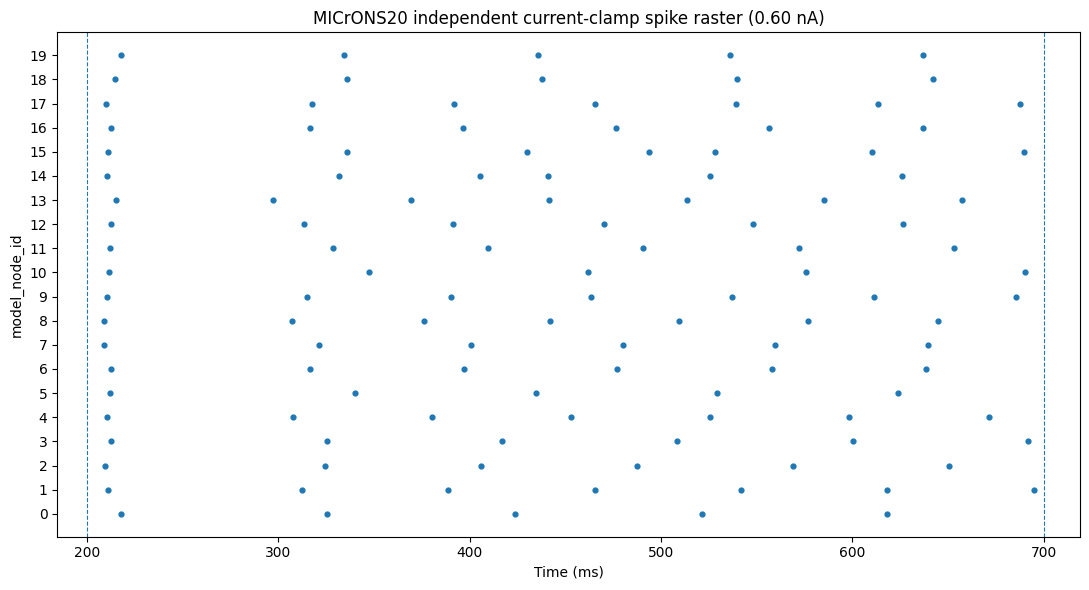

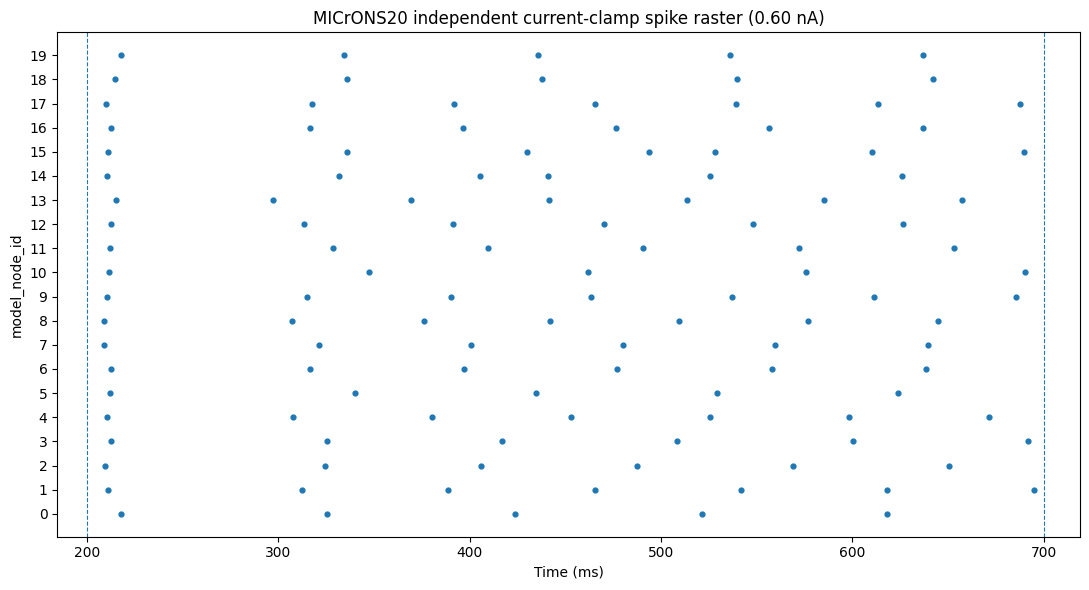

In [8]:
plot_population_spike_raster(run_info)


## 7. Voltage responses

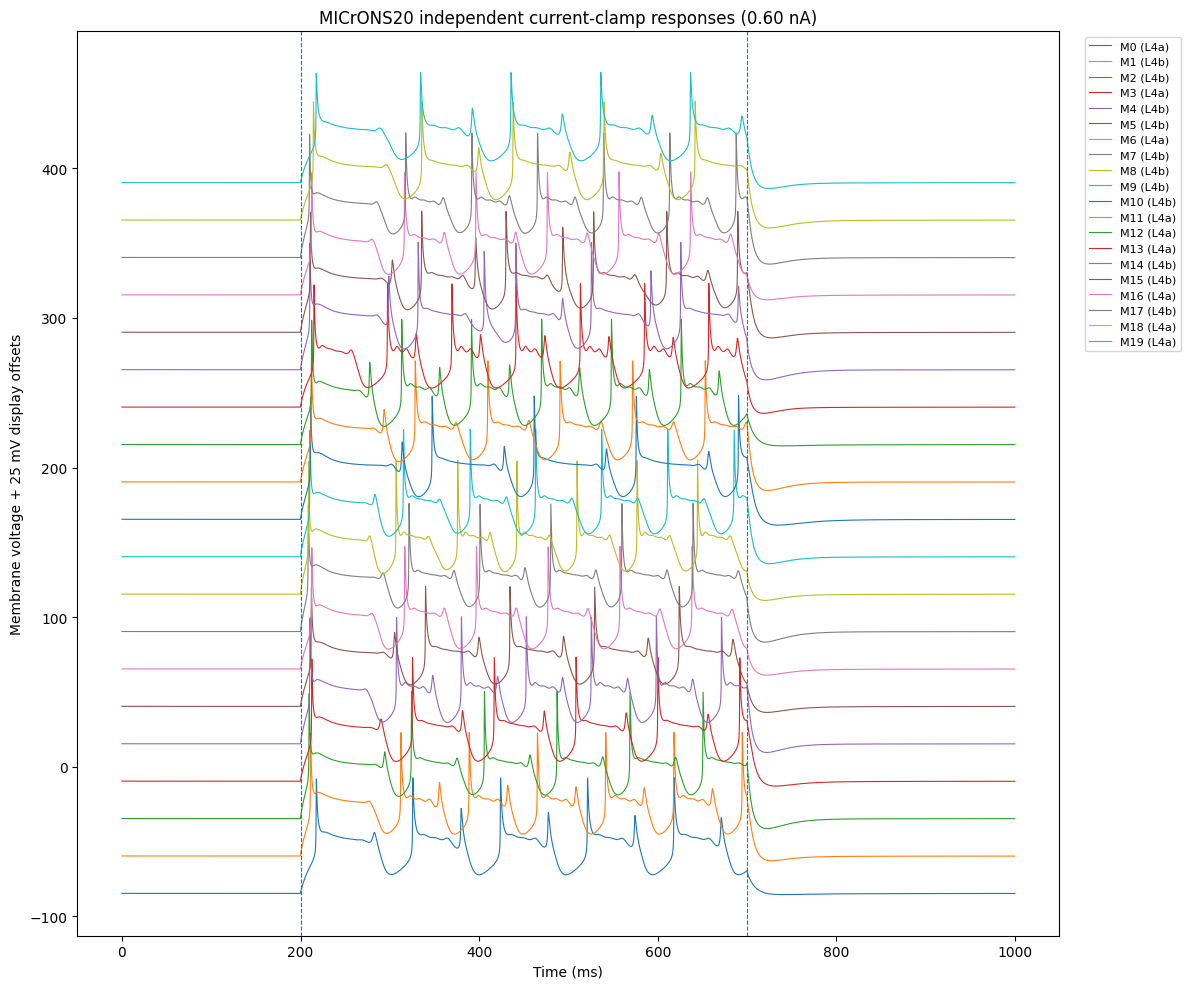

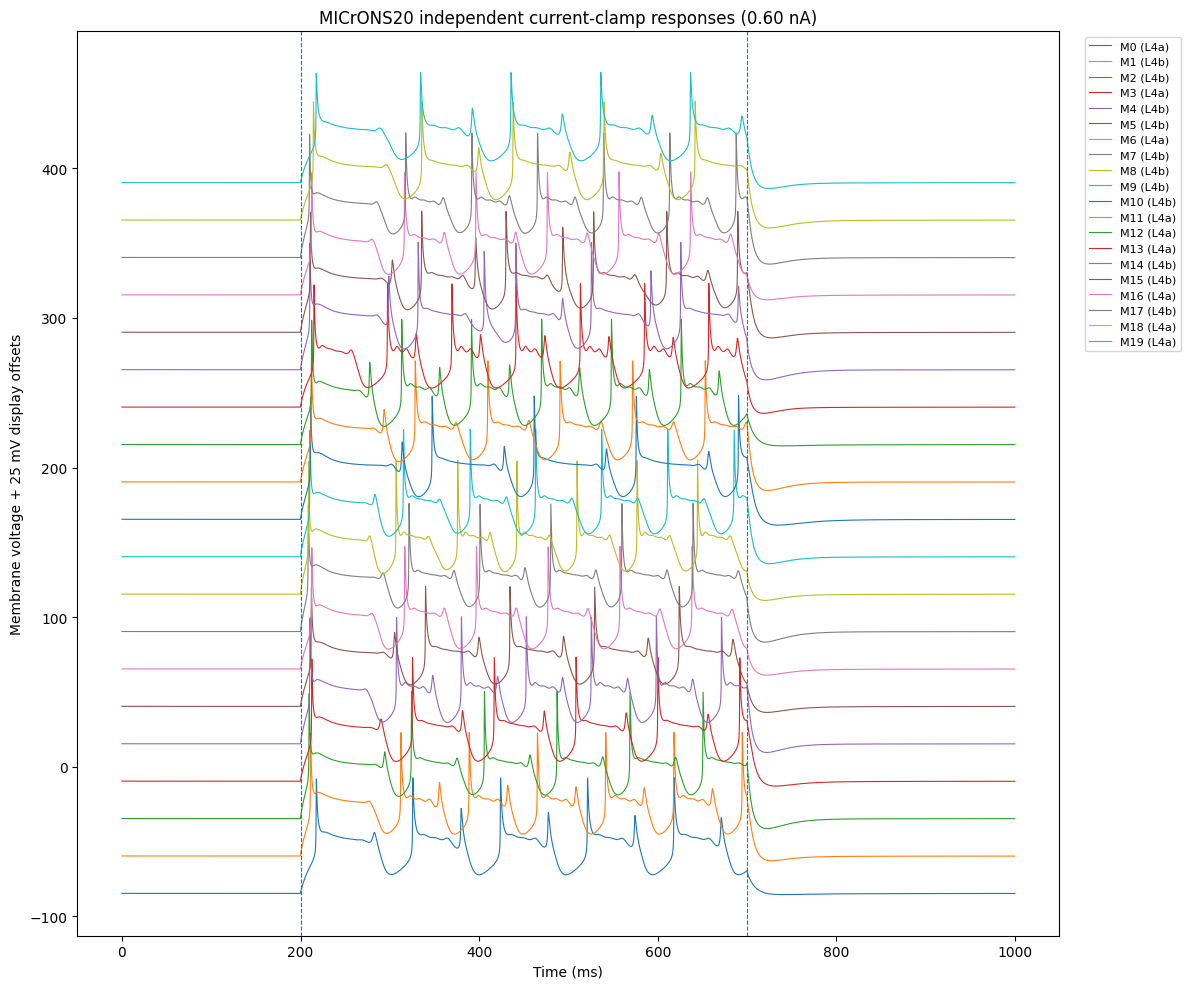

In [9]:
plot_population_voltage_traces(run_info)

## 8. Spike count by neuron

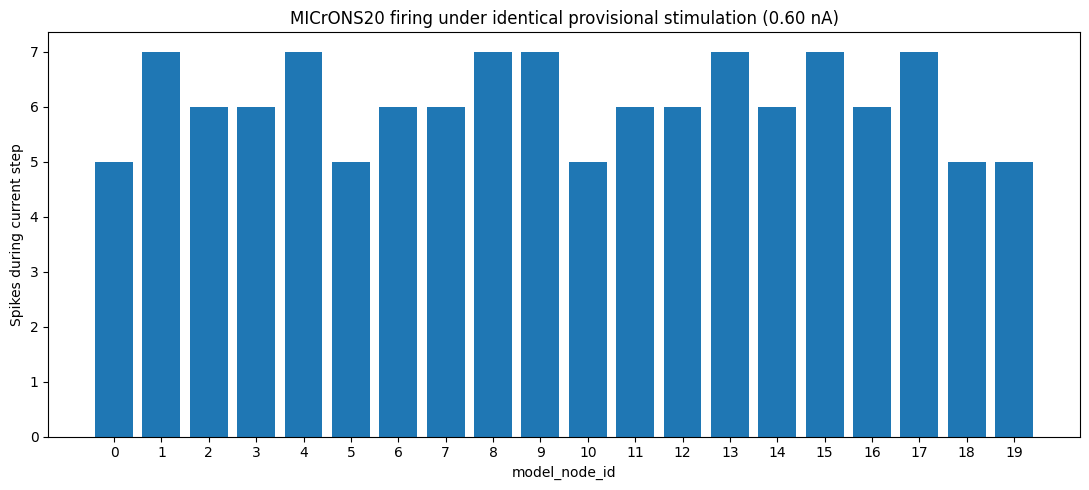

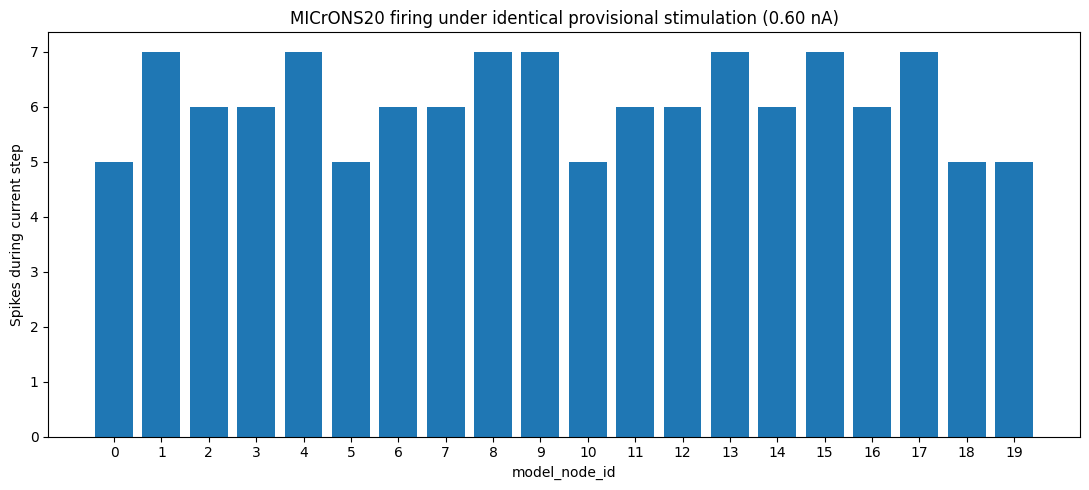

In [10]:
plot_population_spike_counts(
    run_info,
    summary,
)
